# Mutual Fund Selection Strategy — Scoring Model

A systematic, data-driven approach to rank 68 funds across five factors:

| # | Factor | Approach |
|---|--------|----------|
| 1 | **10-Year Return** | Percentile score within universe (missing = adjusted weight) |
| 2 | **5-Year Return** | Percentile score within universe (missing = adjusted weight) |
| 3 | **Stability / Consistency** | Inverse-CV percentile over available long-horizon returns |
| 4 | **Category** | Used for grouping & top-pick-per-category; not a raw score |
| 5 | **Crisil Rating** | Used as a confidence multiplier on the final score |

### Weight scheme (handles missing data gracefully)

| Data available | 10Y wt | 5Y wt | Stability wt |
|---|---|---|---|
| 10Y + 5Y + 3Y | **40%** | **35%** | **25%** |
| 5Y + 3Y (no 10Y) | — | **55%** | **45%** |
| 3Y only (no 5Y, no 10Y) | — | — | **60%** † |

† 3Y return score replaces 5Y in this edge case.

## 1. Setup & Data Loading

In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── aesthetics ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#c9d1d9",
    "axes.facecolor": "#c9d1d9",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#0d1117",
    "xtick.color": "#0d1117",
    "ytick.color": "#0d1117",
    "grid.color": "#21262d",
    "legend.facecolor": "#99bcec",
    "legend.edgecolor": "#c5daf3",
})

PALETTE = [
    "#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
    "#79c0ff","#56d364","#ff7b72","#bc8cff","#e3b341",
    "#1f6feb","#238636",
]

# ── load data ─────────────────────────────────────────────────────────────────
CSV = Path("../mutualfunds/all_funds_moneycontrol.tsv")
df = pd.read_csv(CSV, sep="\t")

RETURN_COLS = ["1W", "1M", "3M", "6M", "YTD", "1Y", "2Y", "3Y", "5Y", "10Y"]

# returns are stored as "32%" strings — strip % and convert to float
for c in RETURN_COLS:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

df["AuM (Cr)"]      = pd.to_numeric(df["AuM (Cr)"], errors="coerce")
df["Crisil Rating"] = pd.to_numeric(df["Crisil Rating"], errors="coerce")

df["Short Name"] = (
    df["Scheme Name"]
    .str.replace(r" - Direct Plan.*", "", regex=True)
    .str.replace(r" - Growth.*", "", regex=True)
    .str.strip()
)


print(f"Total funds  : {len(df)}")
print(f"Have 10Y data: {df['10Y'].notna().sum()}")
print(f"Have 5Y data : {df['5Y'].notna().sum()}")
print(f"Have 3Y data : {df['3Y'].notna().sum()}")
print(f"Category nulls: {df['Category Name'].isna().sum()}")


Total funds  : 924
Have 10Y data: 274
Have 5Y data : 403
Have 3Y data : 539
Category nulls: 0


In [12]:
# keep only shortlist-eligible funds:
# 1. Crisil rating must be 4 or 5
# 2. 5Y return must exist, so new funds are excluded
df = df[df["Crisil Rating"].isin([4, 5])].copy()
df = df[df["5Y"].notna()].copy()

print(f"Eligible funds after filters: {len(df)}")
print(f"4/5-star funds only         : {df['Crisil Rating'].isin([4, 5]).all()}")
print(f"All have 5Y data            : {df['5Y'].notna().all()}")

Eligible funds after filters: 140
4/5-star funds only         : True
All have 5Y data            : True


## 2. Factor Scoring

Each factor is converted to a **0–100 percentile score** so they are on a comparable scale.

### Helper: percentile scorer

```
score = rank(value, ascending) / n × 100
```

Higher score always = better for investment.

In [13]:
def pct_score(series: pd.Series, ascending: bool = True) -> pd.Series:
    """Return 0-100 percentile score; NaN inputs stay NaN."""
    return series.rank(pct=True, ascending=ascending, na_option="keep") * 100


scores = df[["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)",
             "1Y", "3Y", "5Y", "10Y"]].copy()

# ── Factor 1: 10-Year Return ─────────────────────────────────────────────────
scores["score_10Y"] = pct_score(scores["10Y"])

# ── Factor 2: 5-Year Return ──────────────────────────────────────────────────
scores["score_5Y"]  = pct_score(scores["5Y"])

# ── Factor 3: Stability (inverse CV) ─────────────────────────────────────────
# Compute CV over whichever long-horizon columns exist per fund
# At minimum every fund has 1Y and 3Y (we use all available)
STAB_COLS = ["1Y", "3Y", "5Y", "10Y"]
ret_matrix = scores[STAB_COLS]

scores["_mean"]  = ret_matrix.mean(axis=1)
scores["_std"]   = ret_matrix.std(axis=1)
scores["CV"]     = (scores["_std"] / scores["_mean"].abs()) * 100

# Funds where all returns are in same direction (all positive) → reasonable CV
# Low CV = stable → ascending=False so top scorer = most stable
scores["score_stability"] = pct_score(scores["CV"], ascending=False)

scores.drop(columns=["_mean", "_std"], inplace=True)

# ── summary table ─────────────────────────────────────────────────────────────
summary = scores[["Short Name", "Category Name", "Crisil Rating",
                  "10Y", "5Y", "3Y", "CV",
                  "score_10Y", "score_5Y", "score_stability"]]
print("Individual factor scores computed ✓")
print(f"\n10Y score  — non-null: {scores['score_10Y'].notna().sum()},  null: {scores['score_10Y'].isna().sum()}")
print(f"5Y score   — non-null: {scores['score_5Y'].notna().sum()},  null: {scores['score_5Y'].isna().sum()}")
print(f"Stability  — non-null: {scores['score_stability'].notna().sum()},  null: {scores['score_stability'].isna().sum()}")
summary.round(1).head(10)

Individual factor scores computed ✓

10Y score  — non-null: 113,  null: 27
5Y score   — non-null: 140,  null: 0
Stability  — non-null: 140,  null: 0


,Short Name,Category Name,Crisil Rating,10Y,5Y,3Y,CV,score_10Y,score_5Y,score_stability
9,Bandhan Small Cap Dir Gr,Small-Cap,5.0,NaN,22.1,28.3,83.4,NaN,95.7,41.4
19,LIC MF Infrastructure Dir Gr,Equity - Infrastructure,4.0,17.0,22.7,26.8,52.8,76.1,96.4,89.3
26,Franklin Build India Dir Gr,Equity - Infrastructure,5.0,18.4,22.9,25.3,54.5,90.3,97.1,85.7
33,Canara Robeco Infrastructure Dir Gr,Equity - Infrastructure,4.0,17.0,23.0,24.8,47.4,75.2,97.9,96.4
36,Bank of India Manfactrg &Infra Dir Gr,Equity - Infrastructure,5.0,19.1,21.8,24.6,30.1,96.5,95.0,99.3
37,DSP India T.I.G.E.R. Dir Gr,Equity - Infrastructure,4.0,17.6,23.1,24.6,48.6,83.2,99.3,93.6
39,Invesco India Mid Cap Dir Gr,Mid-Cap,5.0,19.0,19.4,24.3,54.5,95.6,86.4,87.1
41,Edelweiss Mid Cap Dir Gr,Mid-Cap,5.0,19.2,20.3,24.0,53.1,98.2,90.7,88.6
44,Nippon India Growth Mid Cap Dir Gr,Mid-Cap,5.0,18.9,20.5,23.8,53.6,94.7,92.1,87.9
46,ICICI Pru MidCap Dir Gr,Mid-Cap,4.0,17.1,18.9,23.6,26.8,77.9,84.3,100.0


### 2.1 Visualise Individual Factor Distributions

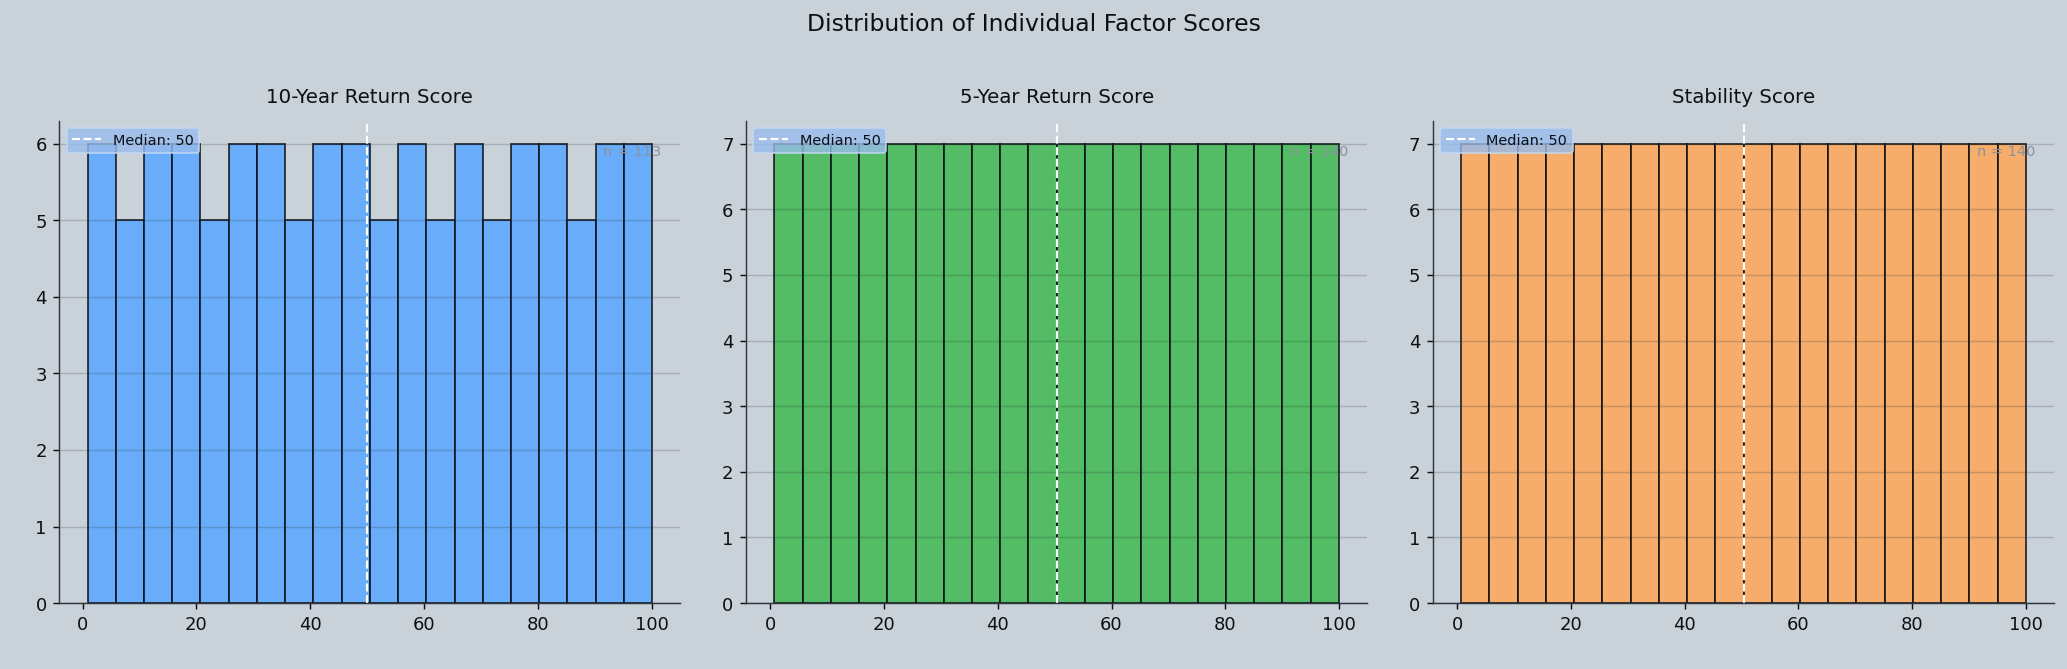

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

factor_meta = [
    ("score_10Y",      "10-Year Return Score", "#58a6ff"),
    ("score_5Y",       "5-Year Return Score",  "#3fb950"),
    ("score_stability","Stability Score",       "#ffa657"),
]

for ax, (col, title, color) in zip(axes, factor_meta):
    data = scores[col].dropna()
    ax.hist(data, bins=20, color=color, alpha=0.85, edgecolor="#0d1117")
    ax.axvline(data.median(), color="white", linewidth=1.2, linestyle="--",
               label=f"Median: {data.median():.0f}")
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Percentile Score (0–100)", fontsize=9)
    ax.set_ylabel("# Funds", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.2)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
    # annotate n
    ax.text(0.97, 0.95, f"n = {len(data)}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#8b949e")

plt.suptitle("Distribution of Individual Factor Scores", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Composite Score

### Weighting Logic

Funds are grouped by data completeness and scored accordingly:

| Tier | Condition | Weights |
|------|-----------|---------|
| **A** — Full history | Has 10Y + 5Y | 40% 10Y + 35% 5Y + 25% Stability |
| **B** — Partial (no 10Y) | Has 5Y, no 10Y | 55% 5Y + 45% Stability |
| **C** — New fund | No 5Y + no 10Y | 60% 3Y + 40% Stability |

### Crisil Rating Multiplier

A 5-star fund gets a **+5% boost**; a 4-star fund gets **no penalty but no bonus**.

### Track Record Multiplier


Tier C funds (5Y only) benefit from a recent bull-market window and have only 2 data points for the stability CV — making their scores unreliable. A discount is applied to reflect this uncertainty:$$\text{Final Score} = \text{Composite} \times \text{RatingMult} \times \text{TrackRecordMult}$$



| Tier | Track Record Mult || C (3Y only) | ×0.85 |

|------|------------------|| B (5Y only) | ×0.95 |
| A (10Y + 5Y) | ×1.00 |

In [15]:
sc = scores.copy()

# ── 3Y score — needed for Tier C ─────────────────────────────────────────────
sc["score_3Y"] = pct_score(sc["3Y"])

# ── assign data tier ──────────────────────────────────────────────────────────
def assign_tier(row):
    if pd.notna(row["10Y"]) and pd.notna(row["5Y"]):
        return "A"   # full history
    elif pd.notna(row["5Y"]):
        return "B"   # 5Y available, 10Y missing
    else:
        return "C"   # only 3Y (newest funds)

sc["data_tier"] = sc.apply(assign_tier, axis=1)

# ── composite score by tier ───────────────────────────────────────────────────
def composite(row):
    t = row["data_tier"]
    if t == "A":
        return 0.40 * row["score_10Y"] + 0.35 * row["score_5Y"] + 0.25 * row["score_stability"]
    elif t == "B":
        return 0.55 * row["score_5Y"] + 0.45 * row["score_stability"]
    else:   # C
        return 0.60 * row["score_3Y"] + 0.40 * row["score_stability"]

sc["composite_score"] = sc.apply(composite, axis=1)

# ── Crisil rating multiplier  (5★ → ×1.05, 4★ → ×1.00) ──────────────────────
sc["rating_mult"] = 1 + (sc["Crisil Rating"] - 4) / 20

# ── Track record multiplier (penalise short history) ─────────────────────────
TRACK_RECORD_MULT = {"A": 1.00, "B": 0.95, "C": 0.85}
sc["track_record_mult"] = sc["data_tier"].map(TRACK_RECORD_MULT)
sc["final_score"] = (sc["composite_score"] * sc["rating_mult"] * sc["track_record_mult"]).round(2)

# ── overall rank ──────────────────────────────────────────────────────────────
sc["rank"] = sc["final_score"].rank(ascending=False, method="min").astype(int)
sc = sc.sort_values("rank").reset_index(drop=True)

tier_counts = sc["data_tier"].value_counts().sort_index()
print("Data tiers:")
for t, n in tier_counts.items():
    label = {"A": "Full (10Y+5Y)", "B": "Partial (5Y only)", "C": "New (3Y only)"}[t]
    print(f"  Tier {t} — {label}: {n} funds")

print(f"4-star funds avg final score : {sc[sc['Crisil Rating']==4]['final_score'].mean():.1f}")

print(f"\nFinal score range: {sc['final_score'].min():.1f} – {sc['final_score'].max():.1f}")
print(f"5-star funds avg final score : {sc[sc['Crisil Rating']==5]['final_score'].mean():.1f}")

Data tiers:
  Tier A — Full (10Y+5Y): 113 funds
  Tier B — Partial (5Y only): 27 funds
4-star funds avg final score : 44.2

Final score range: 3.5 – 101.5
5-star funds avg final score : 61.6


## 4. Full Ranked Leaderboard

In [16]:
TIER_LABEL = {"A": "Full (10Y+5Y)", "B": "Partial (5Y)", "C": "New (3Y)"}

display = sc[[
    "rank", "Short Name", "Category Name", "Crisil Rating", "data_tier",
    "10Y", "5Y", "CV",
    "score_10Y", "score_5Y", "score_stability",
    "composite_score", "final_score"
]].copy()

display["data_tier"]   = display["data_tier"].map(TIER_LABEL)
display["Crisil Rating"] = display["Crisil Rating"].astype(int).apply(lambda r: "★" * r)

for c in ["10Y", "5Y", "CV"]:
    display[c] = display[c].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "—")
for c in ["score_10Y", "score_5Y", "score_stability", "composite_score"]:
    display[c] = display[c].apply(lambda x: f"{x:.0f}" if pd.notna(x) else "—")

display = display.rename(columns={
    "rank": "Rank",
    "Short Name": "Fund",
    "Category Name": "Category",
    "Crisil Rating": "Rating",
    "data_tier": "Data",
    "score_10Y": "S:10Y",
    "score_5Y": "S:5Y",
    "score_stability": "S:Stability",
    "composite_score": "Composite",
    "final_score": "Final ★",
})
display.set_index("Rank", inplace=True)
display

,Fund,Category,Rating,Data,10Y,5Y,CV,S:10Y,S:5Y,S:Stability,Composite,Final ★
Rank,,,,,,,,,,,,
1,Bank of India Manfactrg &Infra Dir Gr,Equity - Infrastructure,★★★★★,Full (10Y+5Y),19.1%,21.8%,30.1%,96,95,99,97,101.49
2,Edelweiss Mid Cap Dir Gr,Mid-Cap,★★★★★,Full (10Y+5Y),19.2%,20.3%,53.1%,98,91,89,93,97.84
3,Nippon India Growth Mid Cap Dir Gr,Mid-Cap,★★★★★,Full (10Y+5Y),18.9%,20.5%,53.6%,95,92,88,92,96.69
4,HDFC Mid Cap Dir Gr,Mid-Cap,★★★★★,Full (10Y+5Y),18.4%,20.7%,49.7%,91,93,92,92,96.60
5,Franklin Build India Dir Gr,Equity - Infrastructure,★★★★★,Full (10Y+5Y),18.4%,22.9%,54.5%,90,97,86,92,96.11
...,...,...,...,...,...,...,...,...,...,...,...,...
136,ICICI Pru ESG Exclsnry Strtgy Dir Gr,Equity - ESG,★★★★,Partial (5Y),—,11.9%,149.5%,—,14,3,9,8.69
137,Mahindra Manulife Lrg Cap Dir Gr,Large-Cap,★★★★,Partial (5Y),—,11.3%,131.9%,—,9,6,8,7.29
138,Kotak ESG Exclusionary Strategy Dir Gr,Equity - ESG,★★★★,Partial (5Y),—,9.5%,118.4%,—,1,12,6,5.94


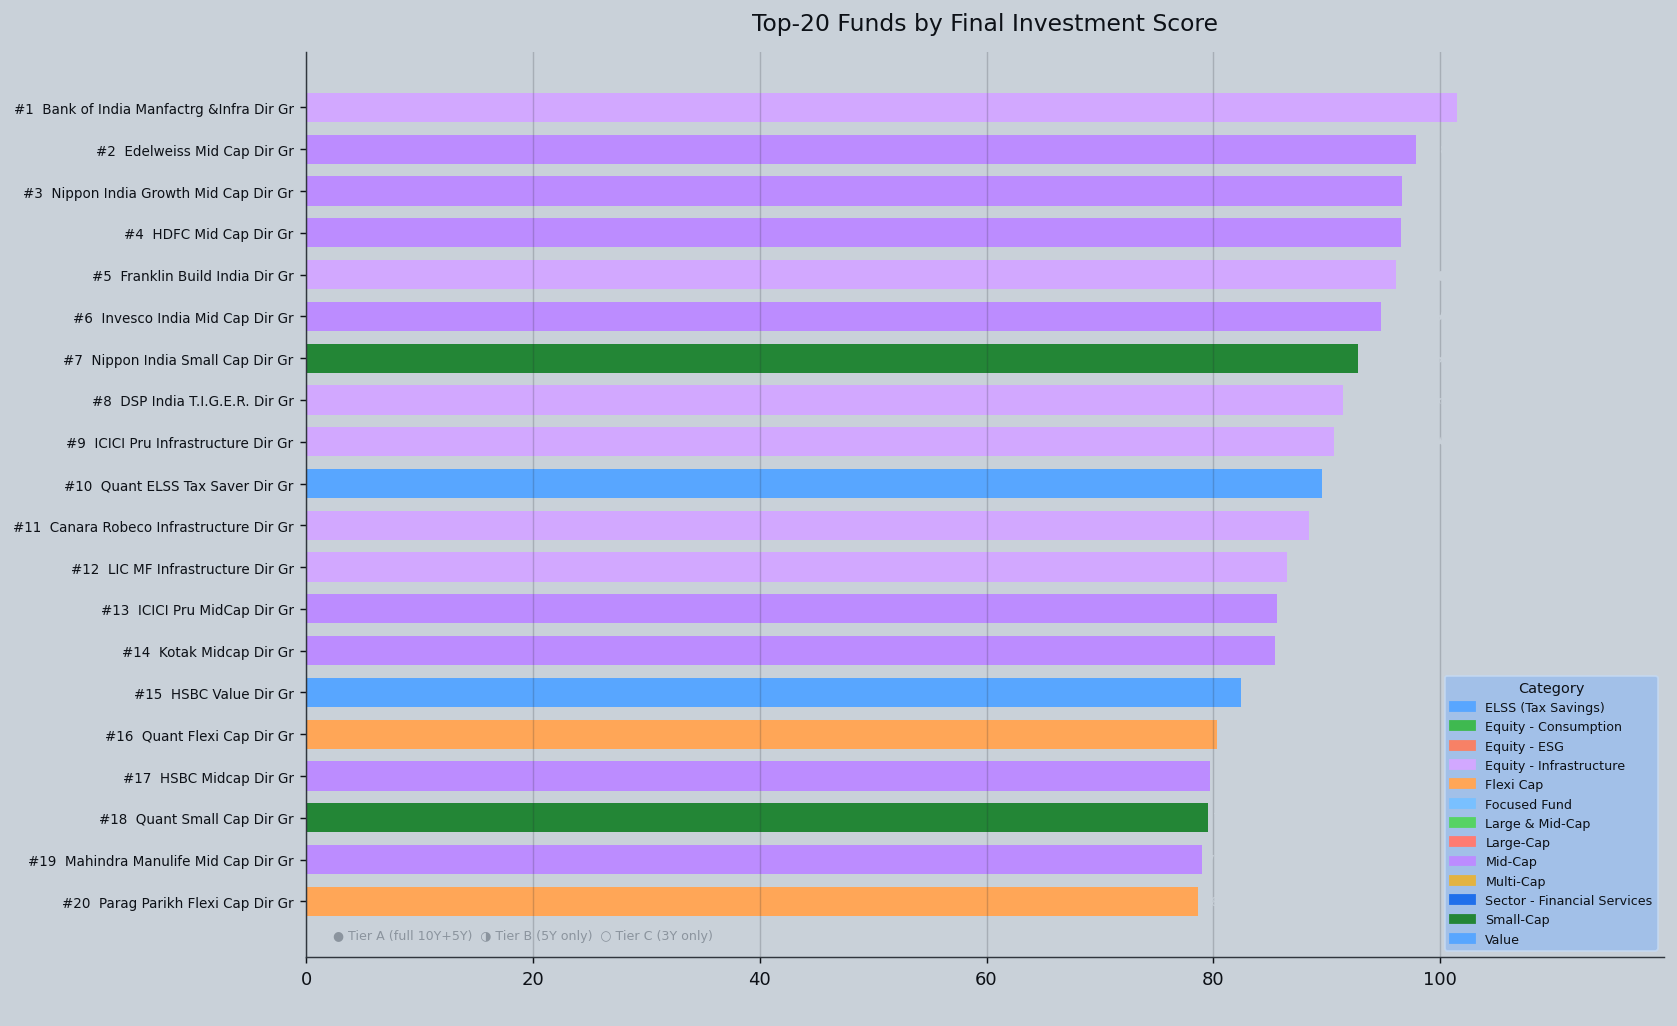

In [17]:
# ── Visual: Top-20 final score horizontal bar ────────────────────────────────
top20 = sc.head(20).copy()
cat_list = sorted(sc["Category Name"].unique())
cat_colors = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(cat_list)}
bar_colors = [cat_colors[c] for c in top20["Category Name"]]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(
    range(len(top20)), top20["final_score"].values[::-1],
    color=bar_colors[::-1], height=0.7
)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(
    [f"#{r}  {n}" for r, n in zip(
        top20["rank"].values[::-1],
        top20["Short Name"].values[::-1]
    )],
    fontsize=7.5
)

# annotate score + tier
for i, (_, row) in enumerate(top20.iloc[::-1].iterrows()):
    tier_badge = {"A": "●", "B": "◑", "C": "○"}[row["data_tier"]]
    stars = "★" * int(row["Crisil Rating"])
    ax.text(
        row["final_score"] + 0.4, i,
        f"{row['final_score']:.1f}  {tier_badge} {stars}",
        va="center", fontsize=7, color="#c9d1d9"
    )

# category legend
handles = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
ax.legend(handles=handles, title="Category", fontsize=7, title_fontsize=8,
          loc="lower right")

ax.set_xlabel("Final Score (0–100+)", fontsize=10)
ax.set_title("Top-20 Funds by Final Investment Score", fontsize=13, pad=12)
ax.set_xlim(0, top20["final_score"].max() * 1.18)
ax.grid(axis="x", alpha=0.2)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# tier legend note
ax.text(0.02, 0.02,
        "● Tier A (full 10Y+5Y)  ◑ Tier B (5Y only)  ○ Tier C (3Y only)",
        transform=ax.transAxes, fontsize=7, color="#8b949e")
plt.tight_layout()
plt.show()

## 5. Results by Category

For each category: distribution of final scores + the **#1 pick**.

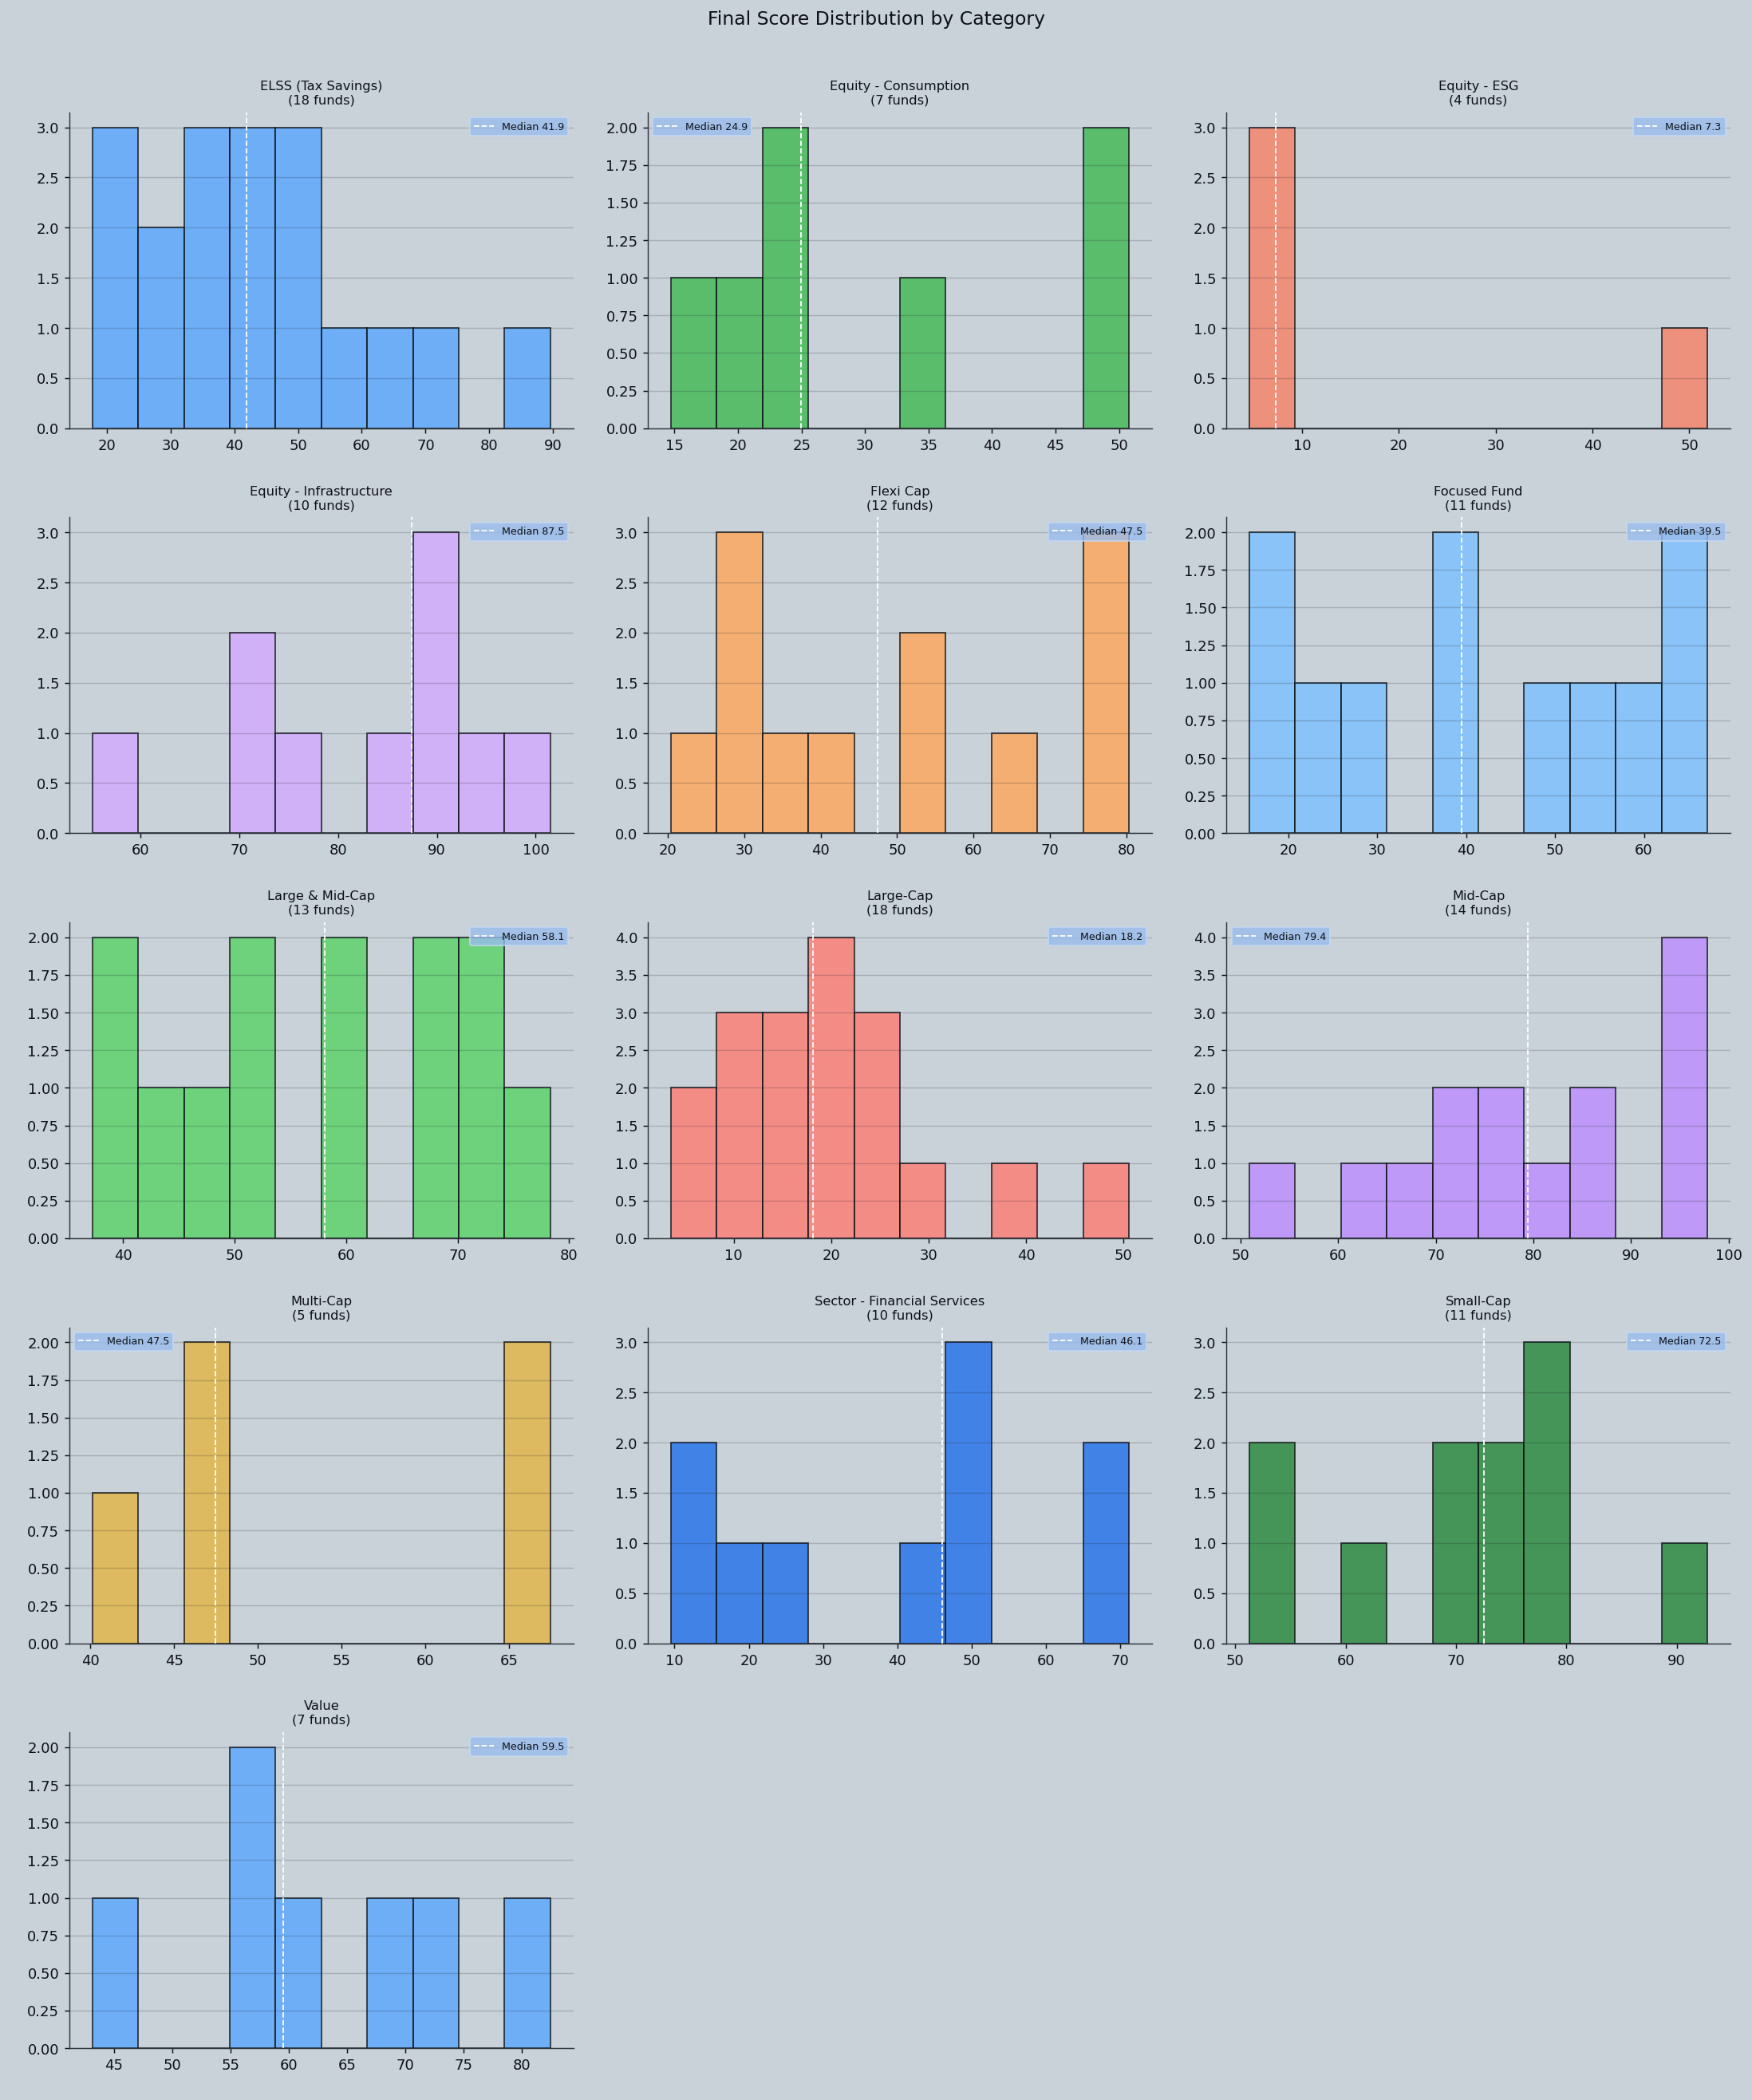

In [18]:
cats = sorted(sc["Category Name"].unique())
n_cats = len(cats)
ncols = 3
nrows = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 4))
axes_flat = axes.flatten()

for i, cat in enumerate(cats):
    ax = axes_flat[i]
    subset = sc[sc["Category Name"] == cat]["final_score"].dropna()
    color  = cat_colors[cat]

    ax.hist(subset, bins=10, color=color, alpha=0.8, edgecolor="#0d1117")
    ax.axvline(subset.median(), color="white", linewidth=1, linestyle="--",
               label=f"Median {subset.median():.1f}")
    ax.set_title(f"{cat}\n({len(subset)} funds)", fontsize=9, pad=6)
    ax.set_xlabel("Final Score", fontsize=7.5)
    ax.set_ylabel("# Funds", fontsize=7.5)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.2)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# hide empty axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Final Score Distribution by Category", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Results by Crisil Rating

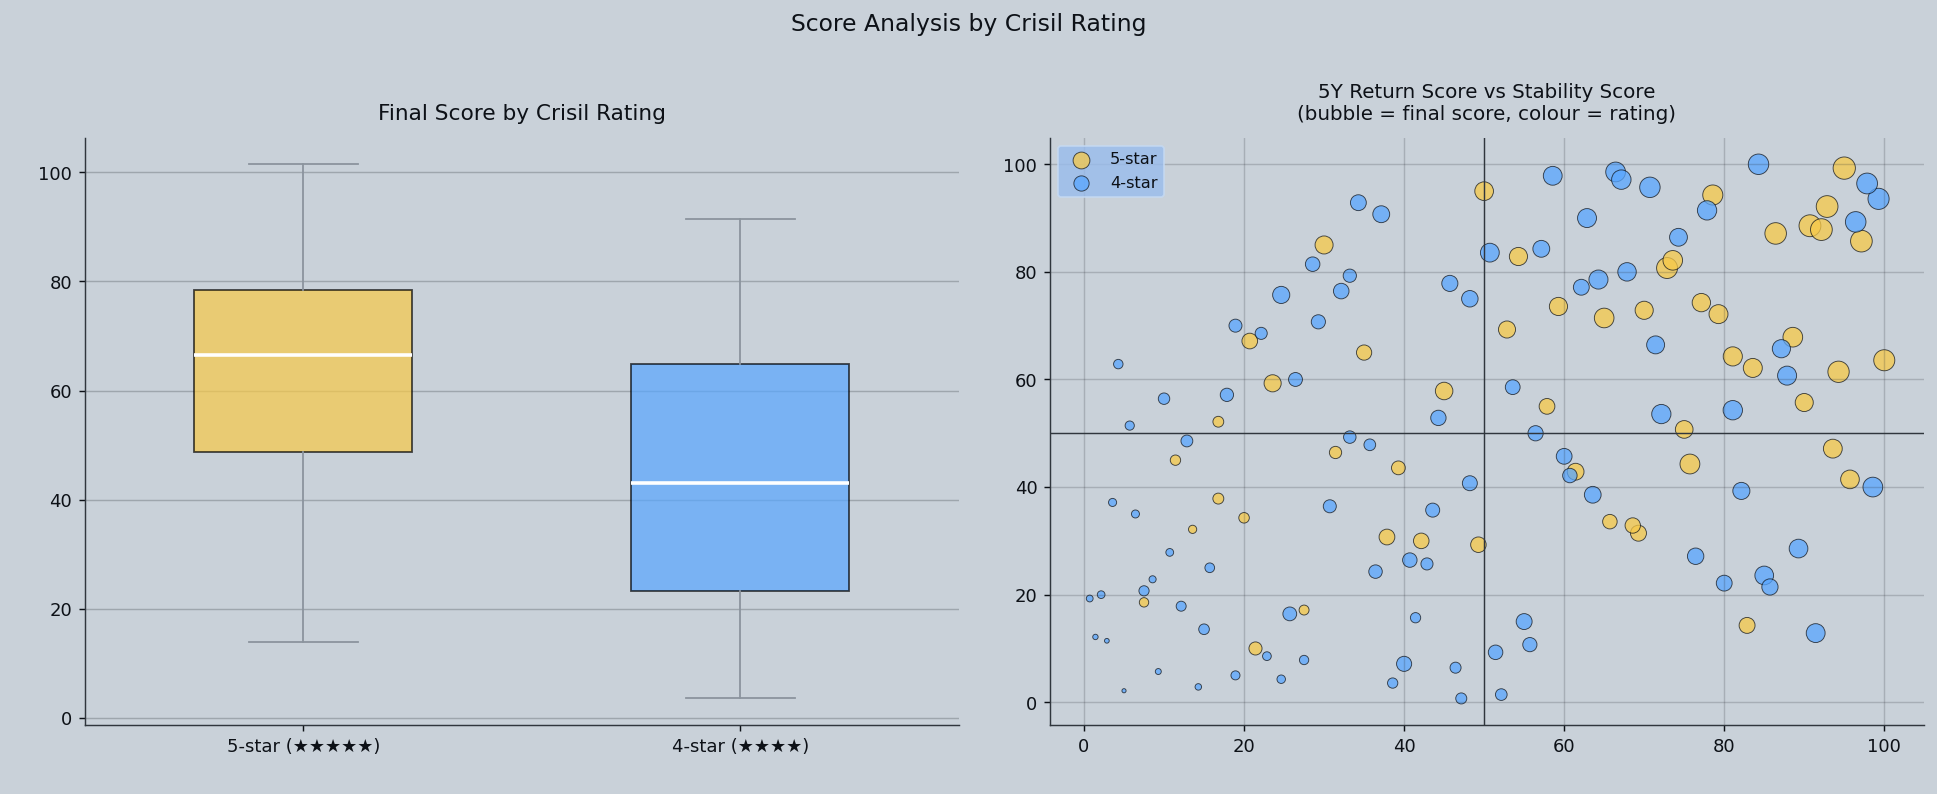

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: box plot of final scores by rating ─────────────────────────────────
rating_groups = [sc[sc["Crisil Rating"] == r]["final_score"].dropna() for r in [5, 4]]
bp = axes[0].boxplot(
    rating_groups,
    labels=["5-star (★★★★★)", "4-star (★★★★)"],
    patch_artist=True,
    widths=0.5,
    medianprops={"color": "white", "linewidth": 2},
    whiskerprops={"color": "#8b949e"},
    capprops={"color": "#8b949e"},
    flierprops={"marker": "o", "color": "#8b949e", "markersize": 4},
)
for patch, color in zip(bp["boxes"], ["#f7c948", "#58a6ff"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel("Final Score", fontsize=10)
axes[0].set_title("Final Score by Crisil Rating", fontsize=12, pad=10)
axes[0].grid(axis="y", alpha=0.25)
for spine in ["top", "right"]: axes[0].spines[spine].set_visible(False)

# stats annotation
for x, grp in enumerate(rating_groups, 1):
    axes[0].text(x, grp.max() + 1, f"avg={grp.mean():.1f}", ha="center",
                 fontsize=8, color="#c9d1d9")

# ── Right: scatter component scores (5Y vs stability) coloured by rating ──────
for r, col, lbl in [(5, "#f7c948", "5-star"), (4, "#58a6ff", "4-star")]:
    sub = sc[sc["Crisil Rating"] == r]
    axes[1].scatter(
        sub["score_5Y"], sub["score_stability"],
        c=col, s=sub["final_score"] * 1.5,
        alpha=0.75, edgecolors="#0d1117", linewidth=0.5, label=lbl,
    )

axes[1].set_xlabel("5-Year Return Score", fontsize=10)
axes[1].set_ylabel("Stability Score", fontsize=10)
axes[1].set_title("5Y Return Score vs Stability Score\n(bubble = final score, colour = rating)",
                  fontsize=11, pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)
axes[1].axvline(50, color="#30363d", linewidth=0.8)
axes[1].axhline(50, color="#30363d", linewidth=0.8)
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)

plt.suptitle("Score Analysis by Crisil Rating", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Radar Charts for Top Picks

Radar (spider) charts for the **top 8 funds** across three axes:
- 10Y Return Score (or 5Y/3Y if unavailable)
- 5Y Return Score (or 3Y if unavailable)
- Stability Score

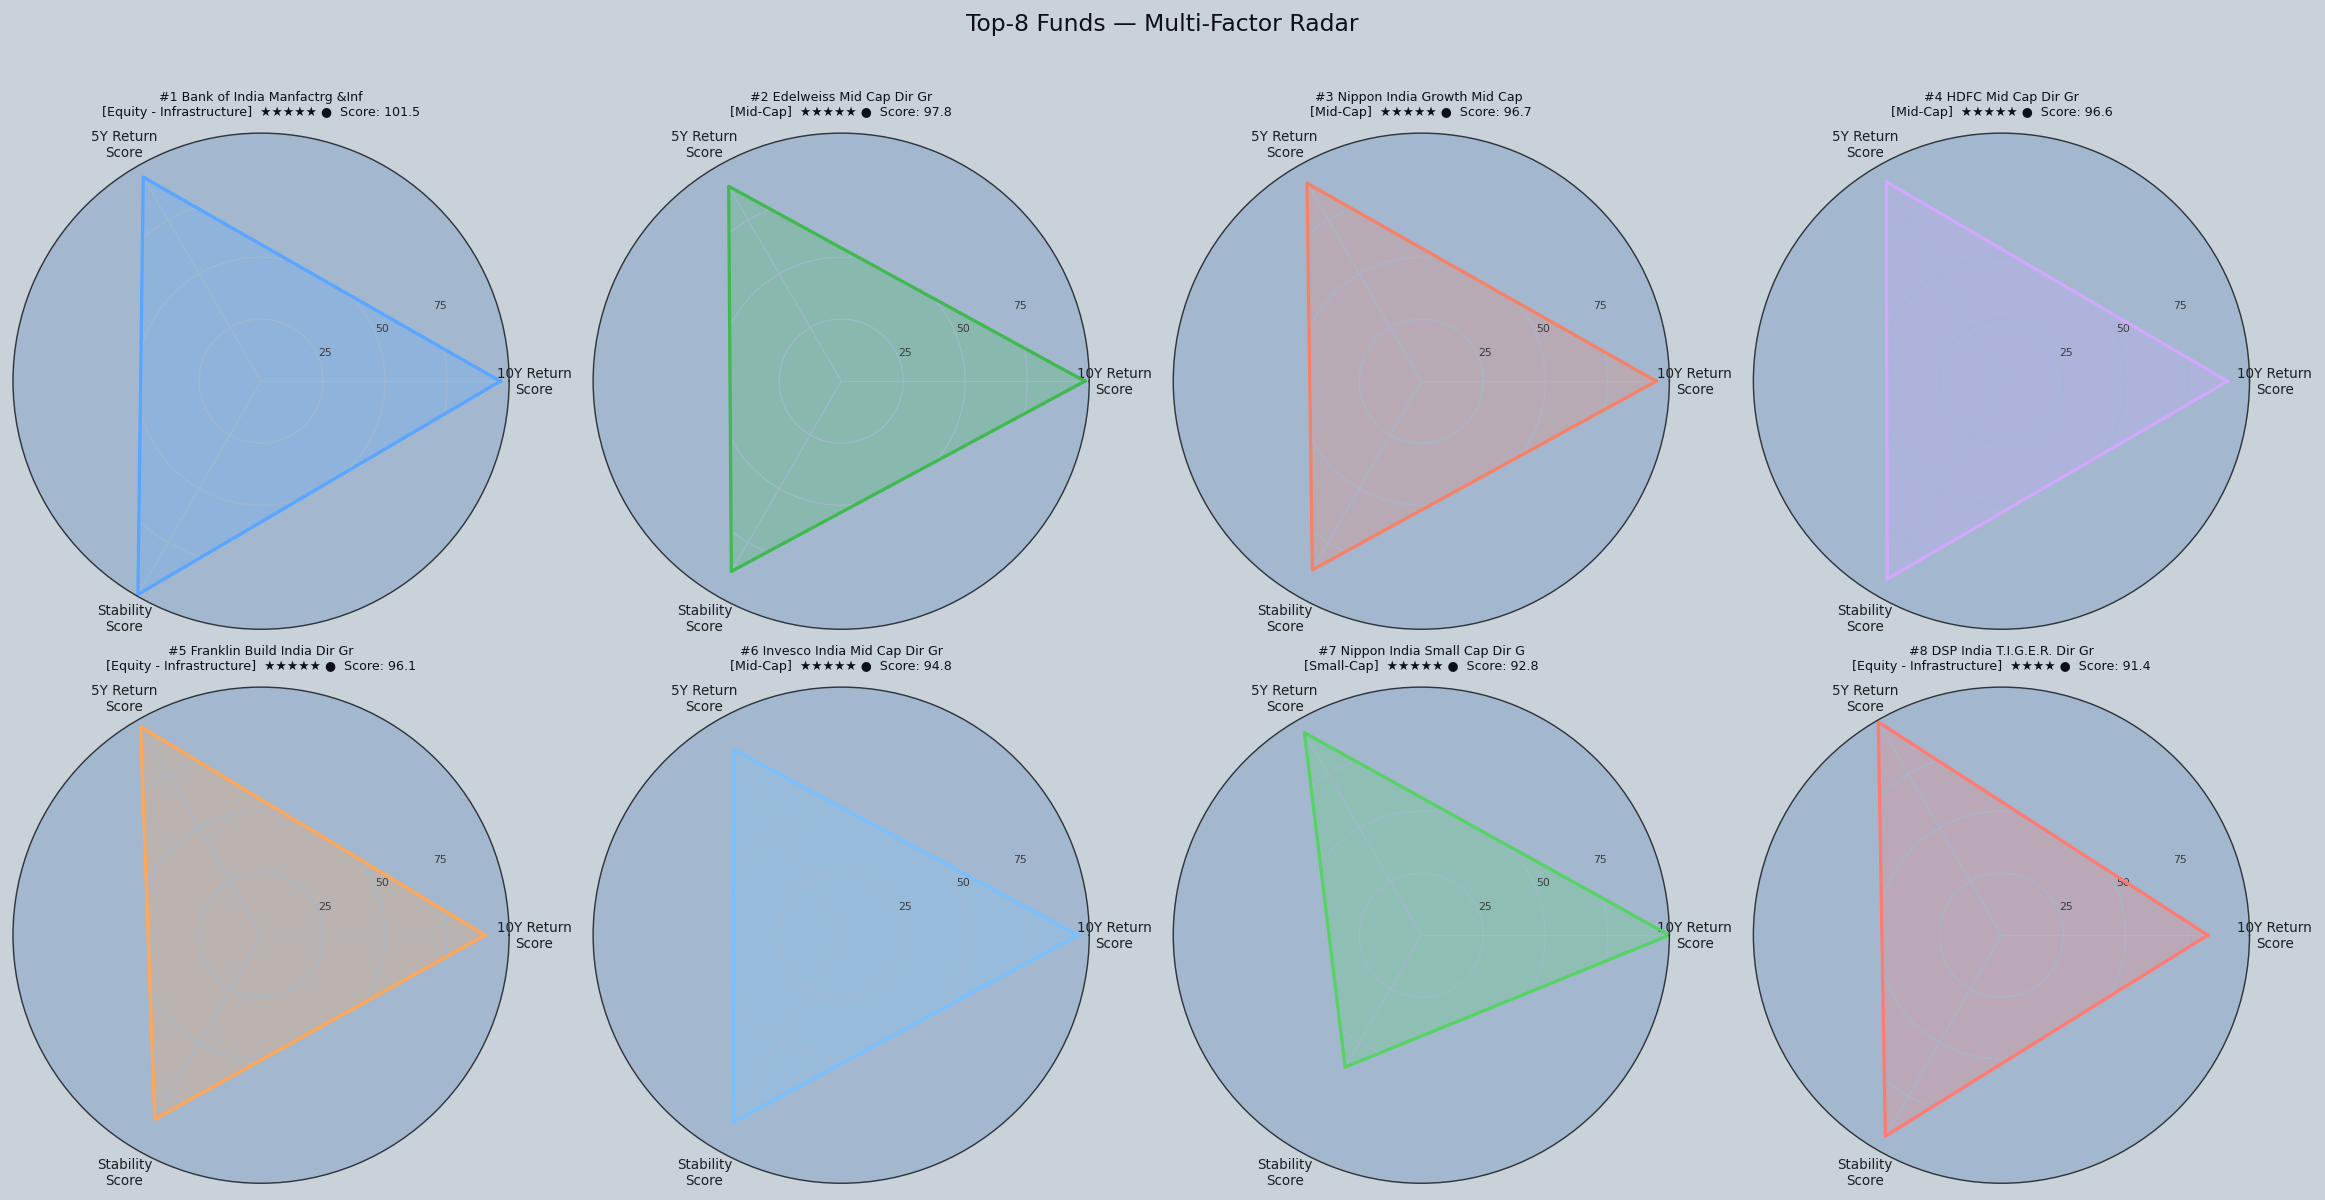

In [28]:
TOP_N = 8
top_funds = sc.head(TOP_N).copy()

# axes: use best available return score for long-horizon axis
top_funds["radar_10Y"]       = top_funds["score_10Y"].fillna(top_funds["score_5Y"]).fillna(top_funds["score_3Y"])
top_funds["radar_5Y"]        = top_funds["score_5Y"].fillna(top_funds["score_3Y"])
top_funds["radar_stability"] = top_funds["score_stability"]

RADAR_LABELS = ["10Y Return\nScore", "5Y Return\nScore", "Stability\nScore"]
N_AXES = len(RADAR_LABELS)
angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 9),
                         subplot_kw={"polar": True})
axes_flat = axes.flatten()

for i, (_, row) in enumerate(top_funds.iterrows()):
    ax     = axes_flat[i]
    color  = PALETTE[i % len(PALETTE)]
    values = [
        row["radar_10Y"],
        row["radar_5Y"],
        row["radar_stability"],
    ]
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=1.8)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=7.5, color="#1d1f20")
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(["25", "50", "75"], fontsize=6, color="#383c40")
    ax.grid(color="#a3b8cf", linewidth=0.6)
    ax.set_facecolor("#a3b8cf")
    ax.spines["polar"].set_color("#30363d")

    tier = row["data_tier"]
    tier_sym = {"A": "●", "B": "◑", "C": "○"}[tier]
    stars = "★" * int(row["Crisil Rating"])
    ax.set_title(
        f"#{int(row['rank'])} {row['Short Name'][:28]}\n"
        f"[{row['Category Name']}]  {stars} {tier_sym}  Score: {row['final_score']:.1f}",
        fontsize=7, pad=10,
    )

# hide unused axes if any
for j in range(TOP_N, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Top-8 Funds — Multi-Factor Radar", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Decision Summary

Bring together:
- Overall top 10 picks  
- Best pick per category (diversified portfolio view)  
- Factor contribution breakdown for the top picks

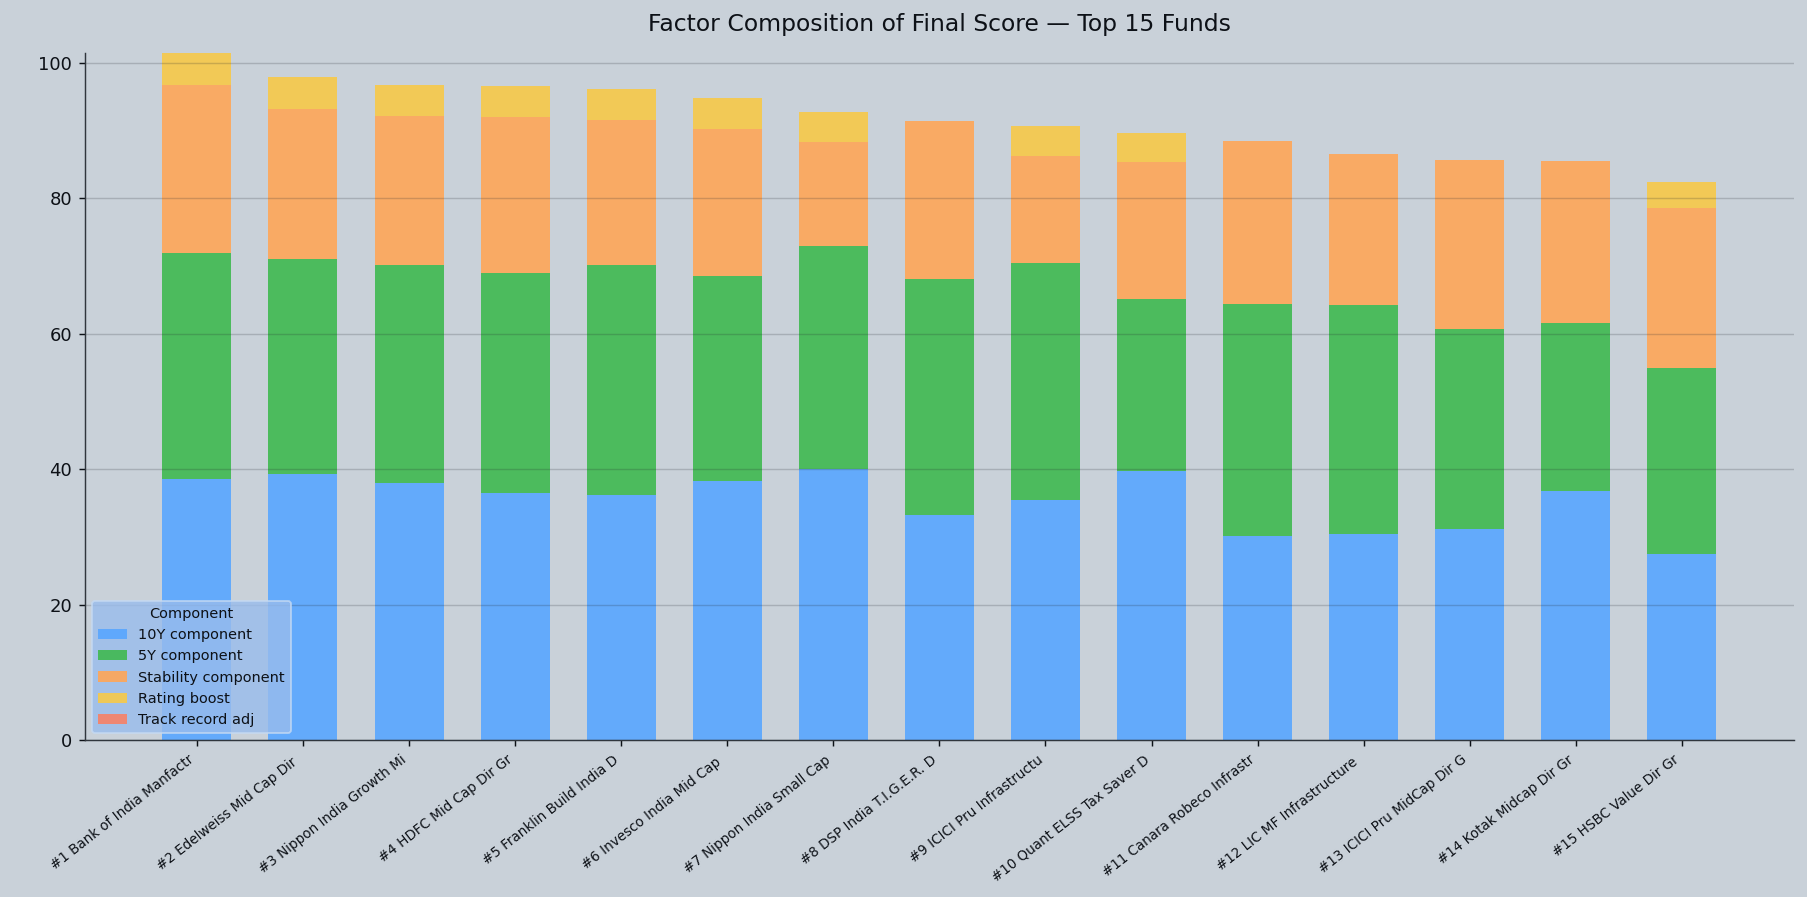

In [22]:
# ── Stacked bar: factor contribution for top-15 ──────────────────────────────
top15 = sc.head(15).copy()

# effective weighted contributions per tier
def factor_contributions(row):
    t = row["data_tier"]
    if t == "A":
        c10  = 0.40 * (row["score_10Y"]       or 0)
        c5   = 0.35 * (row["score_5Y"]        or 0)
        cstb = 0.25 * (row["score_stability"] or 0)
    elif t == "B":
        c10  = 0.0
        c5   = 0.55 * (row["score_5Y"]        or 0)
        cstb = 0.45 * (row["score_stability"] or 0)
    else:
        c10  = 0.0
        c5   = 0.60 * (row["score_3Y"]        or 0)
        cstb = 0.40 * (row["score_stability"] or 0)
    rating_boost  = row["composite_score"] * (row["rating_mult"] - 1)
    tr_discount   = row["composite_score"] * row["rating_mult"] * (row["track_record_mult"] - 1)
    return pd.Series({"10Y component": c10, "5Y component": c5,
                      "Stability component": cstb, "Rating boost": rating_boost,
                      "Track record adj": tr_discount})

contrib = top15.apply(factor_contributions, axis=1)
labels  = [f"#{r} {n[:22]}" for r, n in zip(top15["rank"], top15["Short Name"])]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(top15))
comp_colors = ["#58a6ff", "#3fb950", "#ffa657", "#f7c948", "#f78166"]

for col, color in zip(contrib.columns, comp_colors):
    ax.bar(range(len(top15)), contrib[col], bottom=bottom,
           label=col, color=color, width=0.65, alpha=0.9)
    bottom += contrib[col].values

ax.set_xticks(range(len(top15)))
ax.set_xticklabels(labels, rotation=38, ha="right", fontsize=7.5)
ax.set_ylabel("Score Contribution", fontsize=10)
ax.set_title("Factor Composition of Final Score — Top 15 Funds", fontsize=13, pad=12)
ax.legend(title="Component", fontsize=8, title_fontsize=8)
ax.grid(axis="y", alpha=0.2)

for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [23]:
# ── Best one pick per category (diversified portfolio view) ──────────────────
best_per_cat = (
    sc.sort_values("rank")
    .groupby("Category Name", group_keys=False)
    .head(1)
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("  DIVERSIFIED PORTFOLIO — BEST FUND PER CATEGORY")
print("=" * 80)
for _, row in best_per_cat.iterrows():
    tier_sym = {"A": "●", "B": "◑", "C": "○"}[row["data_tier"]]
    stars    = "★" * int(row["Crisil Rating"])
    ry10 = f"{row['10Y']:.1f}%" if pd.notna(row['10Y']) else "  n/a"
    ry5  = f"{row['5Y']:.1f}%"  if pd.notna(row['5Y'])  else "  n/a"
    print(f"[Rank #{int(row['rank']):>2}] {stars} {tier_sym}  Score: {row['final_score']:5.1f}"
          f"  | 10Y: {ry10:>6}  5Y: {ry5:>6}  CV: {row['CV']:.1f}%"
          f"  | {row['Category Name']}")
    print(f"         {row['Short Name']}")
    print()

print("=" * 80)
print("  OVERALL TOP 10")
print("=" * 80)
for _, row in sc.head(10).iterrows():
    tier_sym = {"A": "●", "B": "◑", "C": "○"}[row["data_tier"]]
    stars    = "★" * int(row["Crisil Rating"])
    ry10 = f"{row['10Y']:.1f}%" if pd.notna(row['10Y']) else "  n/a"
    ry5  = f"{row['5Y']:.1f}%"  if pd.notna(row['5Y'])  else "  n/a"
    print(f"[Rank #{int(row['rank']):>2}] {stars} {tier_sym}  Score: {row['final_score']:5.1f}"
          f"  | 10Y: {ry10:>6}  5Y: {ry5:>6}  CV: {row['CV']:.1f}%"
          f"  | {row['Category Name']}")
    print(f"         {row['Short Name']}")
    print()

  DIVERSIFIED PORTFOLIO — BEST FUND PER CATEGORY
[Rank # 1] ★★★★★ ●  Score: 101.5  | 10Y:  19.1%  5Y:  21.8%  CV: 30.1%  | Equity - Infrastructure
         Bank of India Manfactrg &Infra Dir Gr

[Rank # 2] ★★★★★ ●  Score:  97.8  | 10Y:  19.2%  5Y:  20.3%  CV: 53.1%  | Mid-Cap
         Edelweiss Mid Cap Dir Gr

[Rank # 7] ★★★★★ ●  Score:  92.8  | 10Y:  20.8%  5Y:  21.1%  CV: 73.3%  | Small-Cap
         Nippon India Small Cap Dir Gr

[Rank #10] ★★★★★ ●  Score:  89.6  | 10Y:  20.1%  5Y:  17.9%  CV: 61.0%  | ELSS (Tax Savings)
         Quant ELSS Tax Saver Dir Gr

[Rank #15] ★★★★★ ●  Score:  82.4  | 10Y:  16.7%  5Y:  18.5%  CV: 48.3%  | Value
         HSBC Value Dir Gr

[Rank #16] ★★★★★ ●  Score:  80.3  | 10Y:  19.2%  5Y:  18.3%  CV: 82.0%  | Flexi Cap
         Quant Flexi Cap Dir Gr

[Rank #21] ★★★★★ ●  Score:  78.3  | 10Y:  16.8%  5Y:  18.1%  CV: 59.7%  | Large & Mid-Cap
         Bandhan Large & Mid Cap Dir Gr

[Rank #38] ★★★★★ ●  Score:  71.2  | 10Y:  16.6%  5Y:  14.8%  CV: 48.2%  | Sec

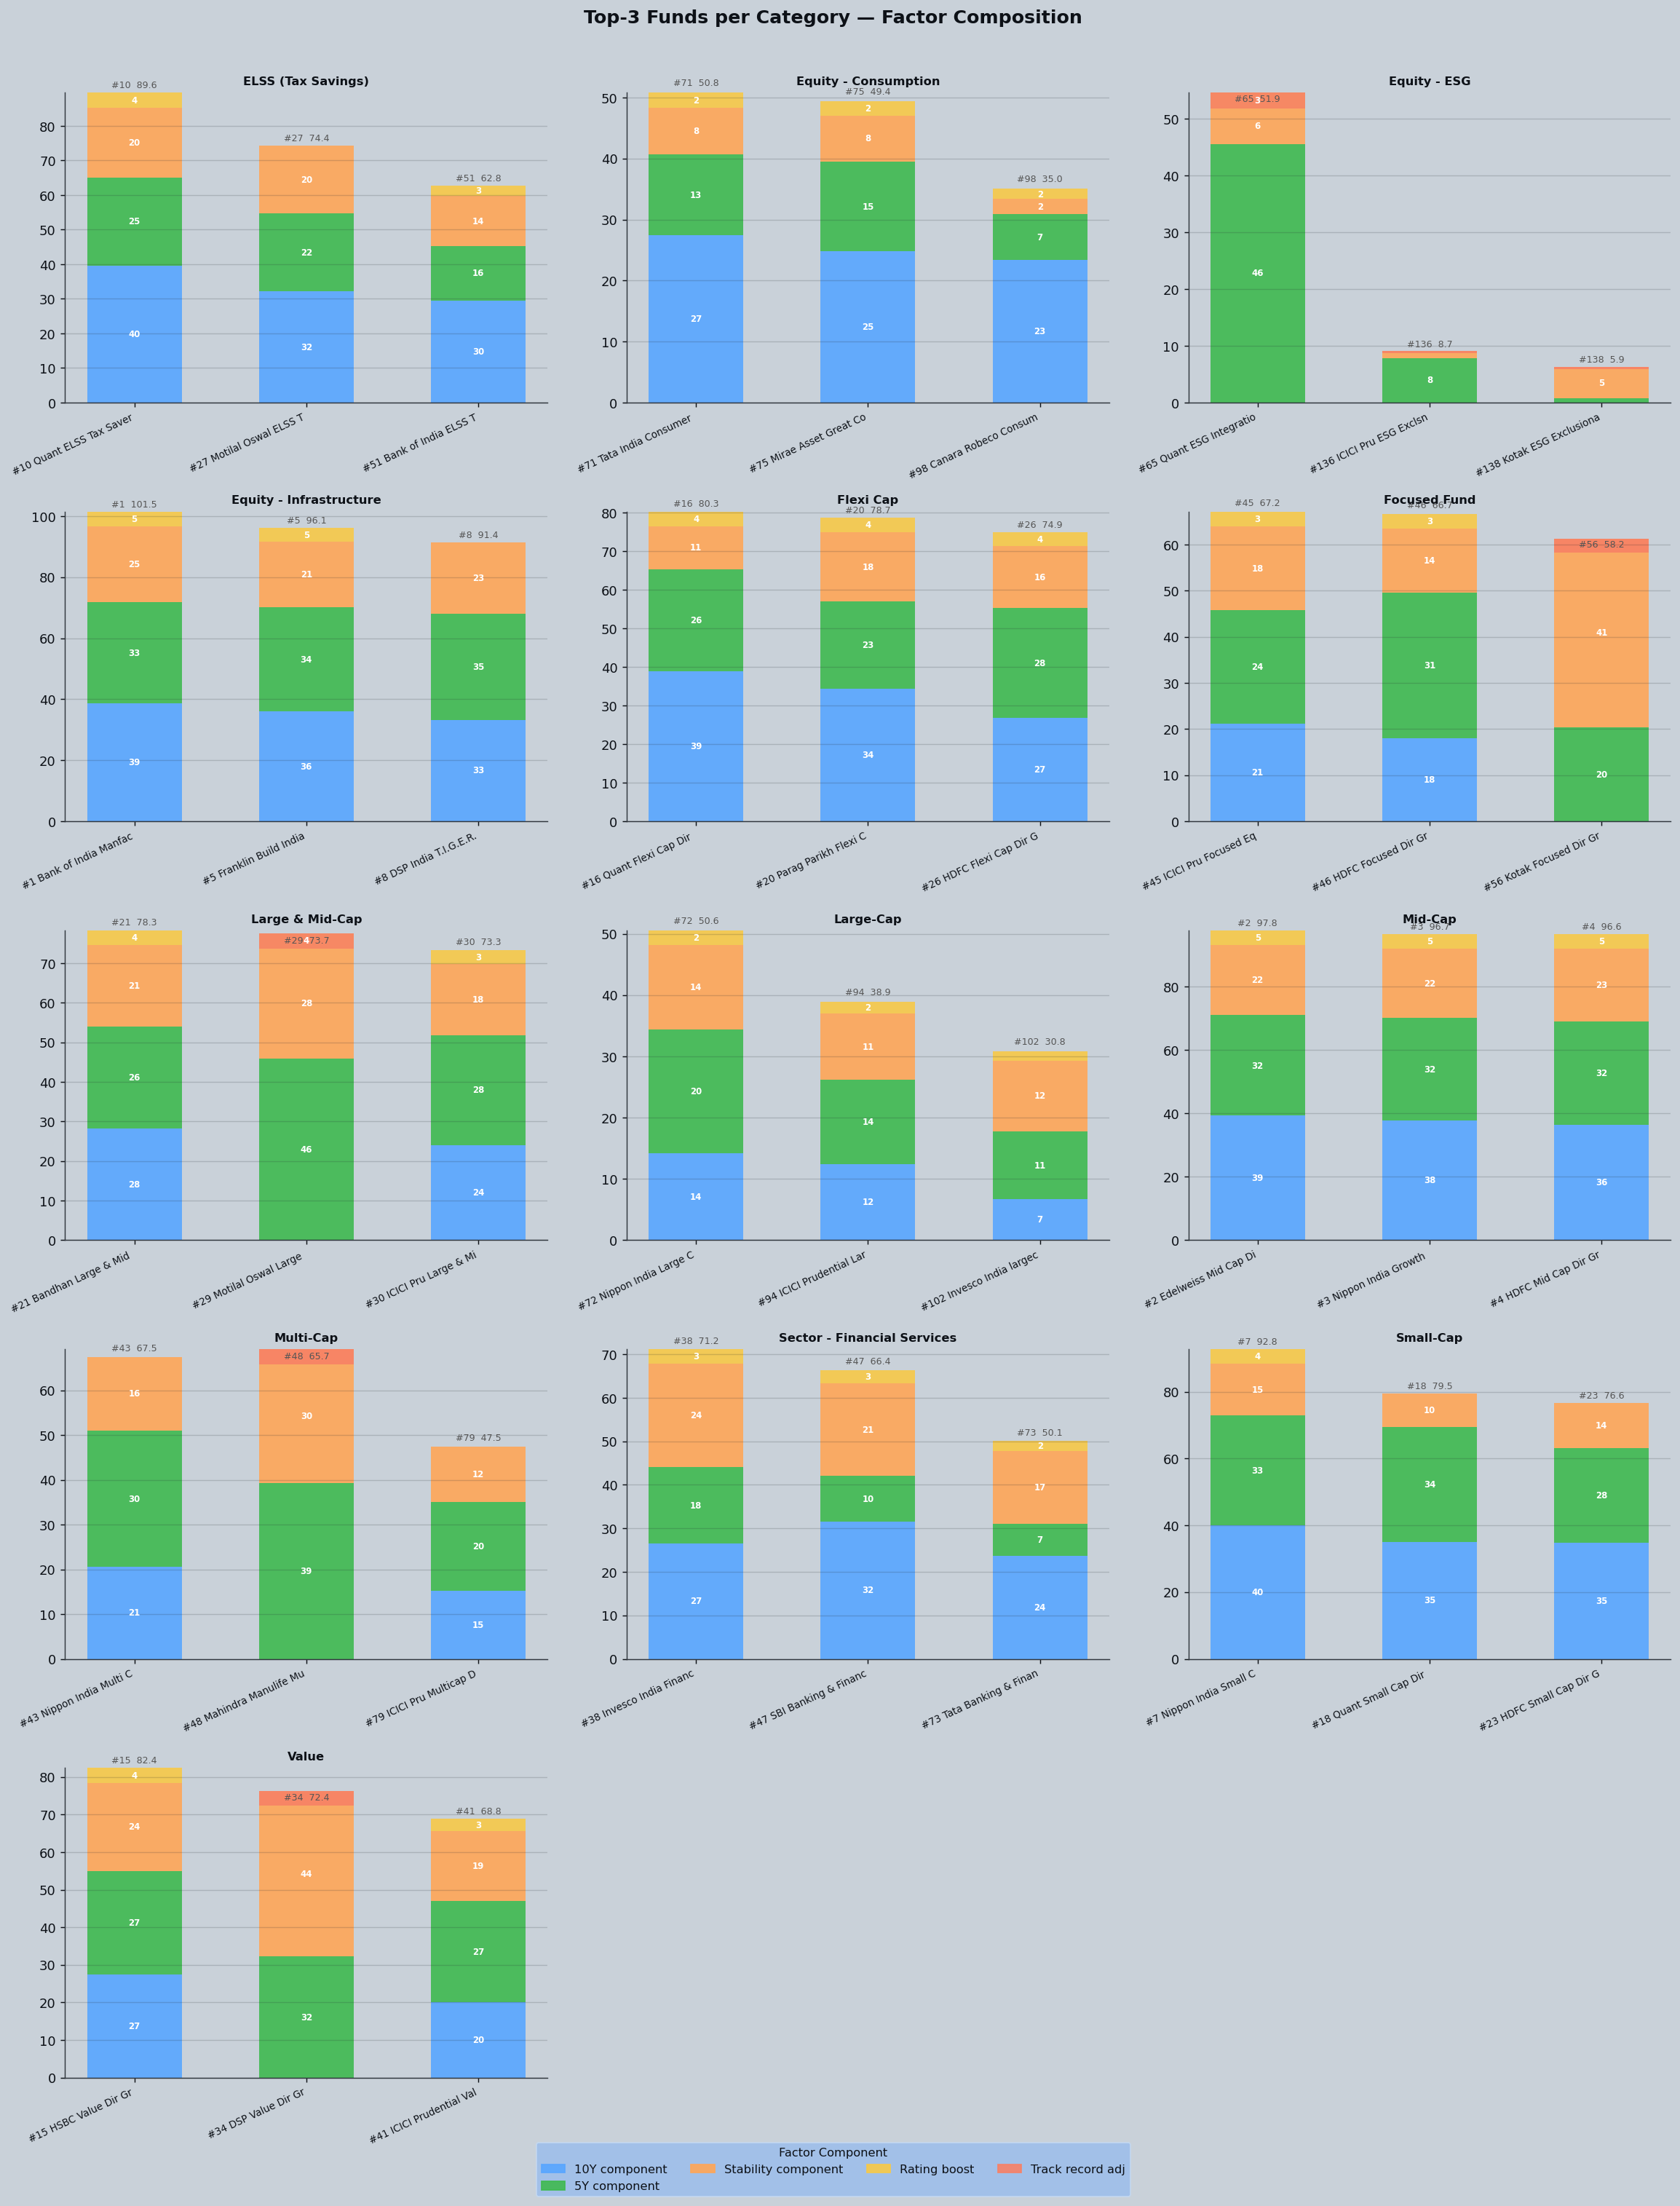

In [24]:

# ── Top 3 per category — factor composition stacked bars ─────────────────────
top3_cat = (
    sc.sort_values("rank")
    .groupby("Category Name", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

contrib3 = top3_cat.apply(factor_contributions, axis=1)
contrib3.index = top3_cat.index

categories = top3_cat["Category Name"].unique()
n_cats     = len(categories)
comp_colors = ["#58a6ff", "#3fb950", "#ffa657", "#f7c948", "#f78166"]
comp_cols   = contrib3.columns.tolist()

# ── layout ───────────────────────────────────────────────────────────────────
ncols = 3
nrows = int(np.ceil(n_cats / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4.5),
                         sharey=False)
axes_flat = axes.flatten() if n_cats > 1 else [axes]

for ax_i, cat in enumerate(sorted(categories)):
    ax   = axes_flat[ax_i]
    mask = top3_cat["Category Name"] == cat
    rows = top3_cat[mask]
    ctb  = contrib3[mask]

    x_pos  = np.arange(len(rows))
    bottom = np.zeros(len(rows))

    for col, color in zip(comp_cols, comp_colors):
        vals = ctb[col].values
        bars = ax.bar(x_pos, vals, bottom=bottom, color=color,
                      label=col, width=0.55, alpha=0.9)
        # annotate non-trivial segments
        for rect, v, bot in zip(bars, vals, bottom):
            if v > 1.5:
                ax.text(rect.get_x() + rect.get_width() / 2,
                        bot + v / 2, f"{v:.0f}",
                        ha="center", va="center", fontsize=6.5,
                        color="white", fontweight="bold")
        bottom += vals

    # annotate total score on top
    for xi, (_, row) in enumerate(rows.iterrows()):
        ax.text(xi, bottom[xi] + 0.8,
                f"#{int(row['rank'])}  {row['final_score']:.1f}",
                ha="center", va="bottom", fontsize=7, color="#555")

    x_labels = [
        f"#{int(r)} {n[:20]}"
        for r, n in zip(rows["rank"], rows["Short Name"])
    ]
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=7.5)
    ax.set_title(cat, fontsize=9, fontweight="bold", pad=6)
    ax.set_ylabel("Score", fontsize=8)
    ax.grid(axis="y", alpha=0.18)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# ── hide empty subplots ───────────────────────────────────────────────────────
for j in range(len(categories), len(axes_flat)):
    axes_flat[j].set_visible(False)

# ── shared legend ─────────────────────────────────────────────────────────────
handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.9)
           for c in comp_colors]
fig.legend(handles, comp_cols, title="Factor Component",
           loc="lower center", ncol=4, fontsize=9,
           title_fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Top-3 Funds per Category — Factor Composition",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [26]:

# ── Funds with final score > 70, grouped by category ─────────────────────────
SCORE_THRESHOLD = 70

high_scorers = (
    sc[sc["final_score"] > SCORE_THRESHOLD]
    .sort_values(["Category Name", "rank"])
    .reset_index(drop=True)
)

out = high_scorers[[
    "rank", "Short Name", "Category Name", "Crisil Rating", "data_tier",
    "10Y", "5Y", "3Y", "1Y", "CV", "final_score"
]].copy()

out["data_tier"]     = out["data_tier"].map(TIER_LABEL)
out["Crisil Rating"] = out["Crisil Rating"].astype(int).apply(lambda r: "★" * r)
for c in ["10Y", "5Y", "3Y"]:
    out[c] = out[c].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "—")
out["CV"]          = out["CV"].apply(lambda x: f"{x:.1f}%")
out["final_score"] = out["final_score"].apply(lambda x: f"{x:.1f}")

out = out.rename(columns={
    "rank": "Rank", "Short Name": "Fund", "Category Name": "Category",
    "Crisil Rating": "Rating", "data_tier": "Data",
    "CV": "CV (Stability)", "final_score": "Score (>70)",
}).set_index(["Category", "Rank"])

print(f"Funds with Final Score > {SCORE_THRESHOLD}: {len(high_scorers)} across "
      f"{high_scorers['Category Name'].nunique()} categories\n")
out


Funds with Final Score > 70: 39 across 8 categories



Fund  \
Category                    Rank                                          
ELSS (Tax Savings)          10              Quant ELSS Tax Saver Dir Gr   
                            27      Motilal Oswal ELSS Tax Saver Dir Gr   
Equity - Infrastructure     1     Bank of India Manfactrg &Infra Dir Gr   
                            5               Franklin Build India Dir Gr   
                            8               DSP India T.I.G.E.R. Dir Gr   
                            9           ICICI Pru Infrastructure Dir Gr   
                            11      Canara Robeco Infrastructure Dir Gr   
                            12             LIC MF Infrastructure Dir Gr   
                            28          HSBC Infrastructure Fund Dir Gr   
                            32              Quant Infrastructure Dir Gr   
                            37      Invesco India Infrastructure Dir Gr   
Flexi Cap                   16                   Quant Flexi Cap Dir Gr   
                            20            Parag Parikh Flexi Cap Dir Gr   
                            26                    HDFC Flexi Cap Dir Gr   
Large & Mid-Cap             21           Bandhan Large & Mid Cap Dir Gr   
                            29      Motilal Oswal Large & Midcap Dir Gr   
                            30         ICICI Pru Large & Mid Cap Dir Gr   
Mid-Cap                     2                  Edelweiss Mid Cap Dir Gr   
                            3        Nippon India Growth Mid Cap Dir Gr   
                            4                       HDFC Mid Cap Dir Gr   
                            6              Invesco India Mid Cap Dir Gr   
                            13                  ICICI Pru MidCap Dir Gr   
                            14                      Kotak Midcap Dir Gr   
                            17                       HSBC Midcap Dir Gr   
                            19         Mahindra Manulife Mid Cap Dir Gr   
                            22              Baroda BNP P Mid Cap Dir Gr   
                            30                      Tata Mid Cap Dir Gr   
                            35                       Axis Midcap Dir Gr   
Sector - Financial Services 38      Invesco India Financial Serv Dir Gr   
Small-Cap                   7             Nippon India Small Cap Dir Gr   
                            18                   Quant Small Cap Dir Gr   
                            23                    HDFC Small Cap Dir Gr   
                            24                     DSP Small Cap Dir Gr   
                            25               Axis Small Cap Fund Dir Gr   
                            33            Invesco India Smallcap Dir Gr   
                            36               HSBC Small Cap Fund Dir Gr   
                            39                 Bandhan Small Cap Dir Gr   
Value                       15                        HSBC Value Dir Gr   
                            34                         DSP Value Dir Gr   

                                 Rating           Data    10Y     5Y     3Y  \
Category                    Rank                                              
ELSS (Tax Savings)          10    ★★★★★  Full (10Y+5Y)  20.1%  17.9%  15.8%   
                            27     ★★★★  Full (10Y+5Y)  17.3%  17.0%  21.6%   
Equity - Infrastructure     1     ★★★★★  Full (10Y+5Y)  19.1%  21.8%  24.6%   
                            5     ★★★★★  Full (10Y+5Y)  18.4%  22.9%  25.3%   
                            8      ★★★★  Full (10Y+5Y)  17.6%  23.1%  24.6%   
                            9     ★★★★★  Full (10Y+5Y)  18.1%  24.4%  21.4%   
                            11     ★★★★  Full (10Y+5Y)  17.0%  23.0%  24.8%   
                            12     ★★★★  Full (10Y+5Y)  17.0%  22.7%  26.8%   
                            28     ★★★★  Full (10Y+5Y)  16.8%  19.8%  19.6%   
                            32     ★★★★  Full (10Y+5Y)  18.9%  20.4%  15.4%   
                            37     ★★★★  Fu